# Multi-wavelength HK calibration (closure)

The paper's calibration recipe (`lucid.fitting.CalibrationParams` + `closure_data` + `calibrate`) on HK
geometry at the HK laser wavelengths (337, 355, 375, 395, 440, 500 nm), with WCSim optics and real
injector diffusers. Scattering, absorption and QE are free per wavelength; wall / PMT reflection and
the per-PMT gains are shared across wavelengths, which is what separates absorption from reflection.
Settings are constants at the top of `hk_multiwavelength_job.py`; this notebook only loads and plots.

In [1]:
import sys

!{sys.executable} hk_multiwavelength_job.py --gpu 5 --out hk_nfwd4.npz --seed 2

[CudaDevice(id=0)]


19746 PMTs | 5 sources x 6 wavelengths | 22 parameters
[time] truth (8 draws): 25 s

[time] Fisher (8 Jacobian draws): 60 s
param                       sigma  most correlated with
scatter_length_337          0.04%  absorption_length_337 (-0.65)
absorption_length_337       1.27%  qe_337 (-0.77)
qe_337                      0.10%  absorption_length_337 (-0.77)
scatter_length_355          0.04%  absorption_length_355 (-0.64)
absorption_length_355       1.36%  qe_355 (-0.78)
qe_355                      0.11%  absorption_length_355 (-0.78)
scatter_length_375          0.05%  absorption_length_375 (-0.63)
absorption_length_375       1.29%  qe_375 (-0.80)
qe_375                      0.11%  absorption_length_375 (-0.80)
scatter_length_395          0.06%  wall_R (+0.64)
absorption_length_395       1.06%  qe_395 (-0.81)
qe_395                      0.11%  absorption_length_395 (-0.81)
scatter_length_440          0.08%  wall_R (+0.63)
absorption_length_440       0.50%  qe_440 (-0.85)
qe_440         

In [1]:
import numpy as np
import matplotlib.pyplot as plt

r = np.load('hk_nfwd4.npz')
names, truth, start, fit, free = list(r['names']), r['truth'], r['start'], r['fit'], r['free']
wls = list(r['wavelengths'])
err = fit / truth - 1

print(f'{len(r["source_labels"])} sources x {len(wls)} wavelengths | intensity {float(r["intensity"]):.0e} | seed {int(r["seed"])}')
print(f'{"param":24s}{"truth":>10s}{"start":>10s}{"fit":>10s}{"err":>9s}')
for n, tr, st, ft, e, fr in zip(names, truth, start, fit, err, free):
    print(f'{n:24s}{tr:10.4g}{st:10.4g}{ft:10.4g}{e:+9.1%}' + ('' if fr else '  (fixed)'))
print(f'\nper-PMT gain residual RMS: {np.std(r["gains"] / r["truth_k"] - 1):.2%}')

5 sources x 6 wavelengths | intensity 1e+08 | seed 2
param                        truth     start       fit      err
scatter_length_337            56.9     37.35     57.04    +0.3%
absorption_length_337        830.7      1037       773    -6.9%
qe_337                      0.3145    0.2298    0.3142    -0.1%
scatter_length_355            73.8     234.1        74    +0.3%
absorption_length_355        853.4     588.9     785.6    -8.0%
qe_355                      0.3324    0.2674    0.3322    -0.1%
scatter_length_375            96.6     71.03     96.89    +0.3%
absorption_length_375        768.1     931.5     729.4    -5.0%
qe_375                      0.3337    0.3708    0.3328    -0.3%
scatter_length_395           124.3     262.8     124.7    +0.4%
absorption_length_395        599.3       616     559.1    -6.7%
qe_395                      0.3311    0.3137    0.3311    +0.0%
scatter_length_440           208.1     66.93     209.1    +0.5%
absorption_length_440        247.4     194.9     23

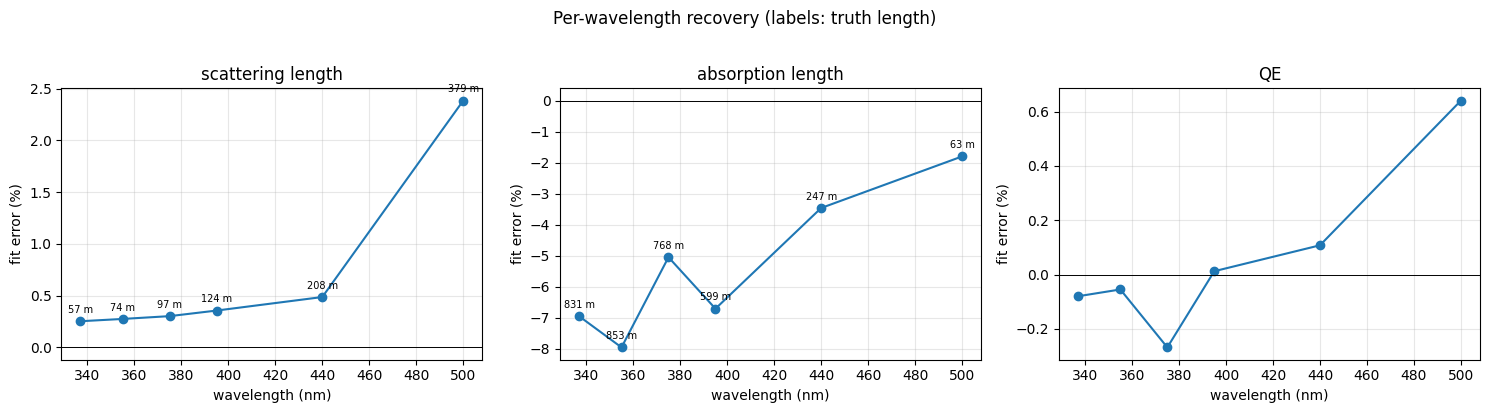

In [2]:
W = len(wls)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, (q, label) in enumerate([('scatter_length', 'scattering length'),
                                 ('absorption_length', 'absorption length'), ('qe', 'QE')]):
    e = np.array([err[names.index(f'{q}_{w}')] for w in wls])
    tv = np.array([truth[names.index(f'{q}_{w}')] for w in wls])
    ax[i].plot(wls, 100 * e, 'o-')
    ax[i].axhline(0, color='k', lw=.7)
    ax[i].set(xlabel='wavelength (nm)', ylabel='fit error (%)', title=label)
    ax[i].grid(alpha=.3)
    if q != 'qe':
        for w, t, y in zip(wls, tv, 100 * e):
            ax[i].annotate(f'{t:.0f} m', (w, y), textcoords='offset points', xytext=(0, 6),
                           ha='center', fontsize=7)
fig.suptitle('Per-wavelength recovery (labels: truth length)', y=1.02)
fig.tight_layout(); plt.show()

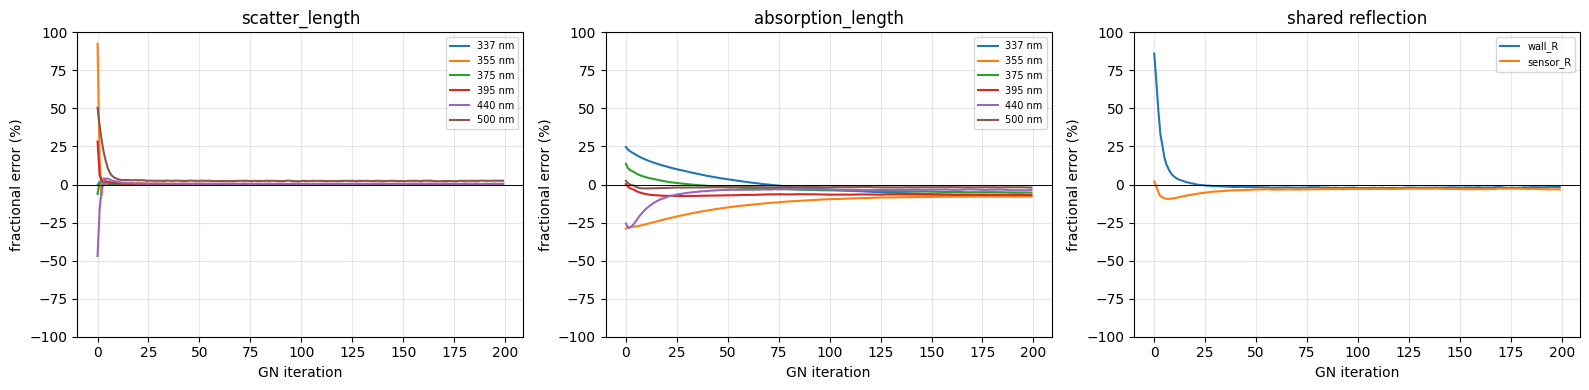

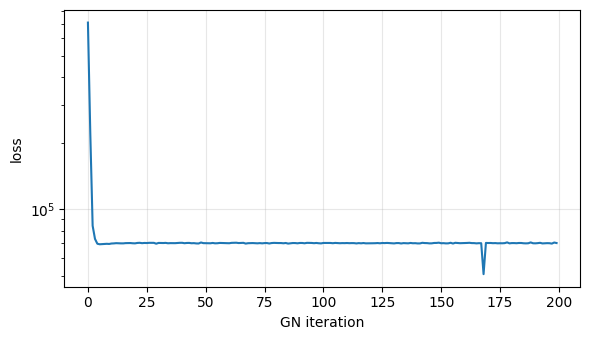

In [3]:
h = r['history'] / truth - 1
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for i, q in enumerate(['scatter_length', 'absorption_length']):
    for w in wls:
        ax[i].plot(100 * h[:, names.index(f'{q}_{w}')], label=f'{w} nm')
    ax[i].set(title=q, ylim=(-100, 100))
for n in ['wall_R', 'wall_fspec', 'sensor_R', 'sensor_fspec']:
    if free[names.index(n)]:
        ax[2].plot(100 * h[:, names.index(n)], label=n)
ax[2].set(title='shared reflection', ylim=(-100, 100))
for a in ax:
    a.axhline(0, color='k', lw=.7); a.set(xlabel='GN iteration', ylabel='fractional error (%)')
    a.grid(alpha=.3); a.legend(fontsize=7)
fig.tight_layout(); plt.show()

plt.figure(figsize=(6, 3.5)); plt.semilogy(r['loss']); plt.xlabel('GN iteration'); plt.ylabel('loss')
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

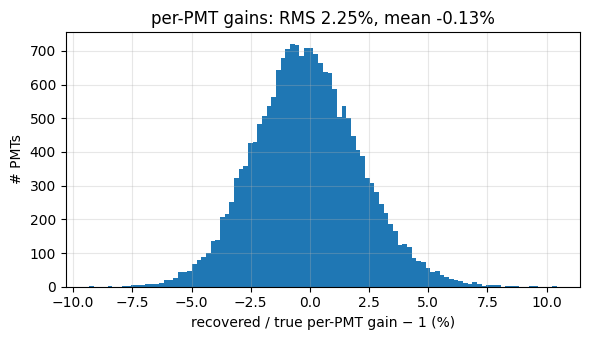

In [4]:
d = r['gains'] / r['truth_k'] - 1
plt.figure(figsize=(6, 3.5))
plt.hist(100 * d, bins=100)
plt.xlabel('recovered / true per-PMT gain − 1 (%)'); plt.ylabel('# PMTs')
plt.title(f'per-PMT gains: RMS {np.std(d):.2%}, mean {np.mean(d):+.2%}')
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

chi2 fit - truth = -4286.4 +- 1847.7  (12/16 draws favour the fit; < 0: minimum displaced from truth)



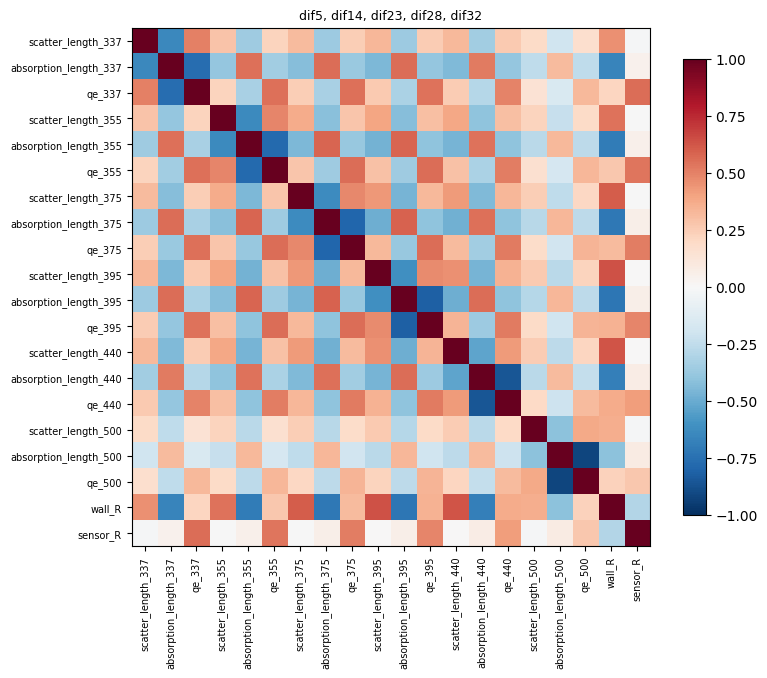

param                    sigma (raw)
scatter_length_337             0.04%
absorption_length_337          1.27%
qe_337                         0.10%
scatter_length_355             0.04%
absorption_length_355          1.36%
qe_355                         0.11%
scatter_length_375             0.05%
absorption_length_375          1.29%
qe_375                         0.11%
scatter_length_395             0.06%
absorption_length_395          1.06%
qe_395                         0.11%
scatter_length_440             0.08%
absorption_length_440          0.50%
qe_440                         0.13%
scatter_length_500             0.14%
absorption_length_500          0.18%
qe_500                         0.18%
wall_R                         0.34%
sensor_R                       0.22%

corr(abs_len_wl, X)          337     355     375     395     440     500
wall_R                     -0.66   -0.70   -0.72   -0.72   -0.69   -0.41
sensor_R                   +0.05   +0.05   +0.06   +0.06   +0.08   +0.08
sca

In [5]:
# chi2(fit) vs chi2(truth) check and Fisher at truth (gains marginalised), for the run loaded above.
# sigma is the raw engine bound (x sqrt(12): honest).
if 'chi2_fit' in r.files and r['chi2_fit'].size:
    d = r['chi2_fit'] - r['chi2_truth']
    print(f'chi2 fit - truth = {d.mean():+.1f} +- {d.std(ddof=1) / np.sqrt(d.size):.1f}  '
          f'({(d < 0).sum()}/{d.size} draws favour the fit; < 0: minimum displaced from truth)\n')

if 'corr' in r.files:
    fn, c, sig = list(r['fisher_names']), r['corr'], r['sigma']
    plt.figure(figsize=(8, 7))
    plt.imshow(c, cmap='RdBu_r', vmin=-1, vmax=1); plt.colorbar(shrink=.8)
    plt.xticks(range(len(fn)), fn, rotation=90, fontsize=7); plt.yticks(range(len(fn)), fn, fontsize=7)
    plt.title(', '.join(r['source_labels']), fontsize=9); plt.tight_layout(); plt.show()

    print(f'{"param":24s}{"sigma (raw)":>12s}')
    for n, s in zip(fn, sig):
        print(f'{n:24s}{s:12.2%}')

    print(f'\n{"corr(abs_len_wl, X)":24s}' + ''.join(f'{w:>8d}' for w in wls))
    for x in ('wall_R', 'sensor_R', 'scatter_length'):
        cols = [fn.index(x if x in fn else f'{x}_{w}') for w in wls]
        print(f'{x:24s}' + ''.join(f'{c[fn.index(f"absorption_length_{w}"), j]:+8.2f}' for w, j in zip(wls, cols)))

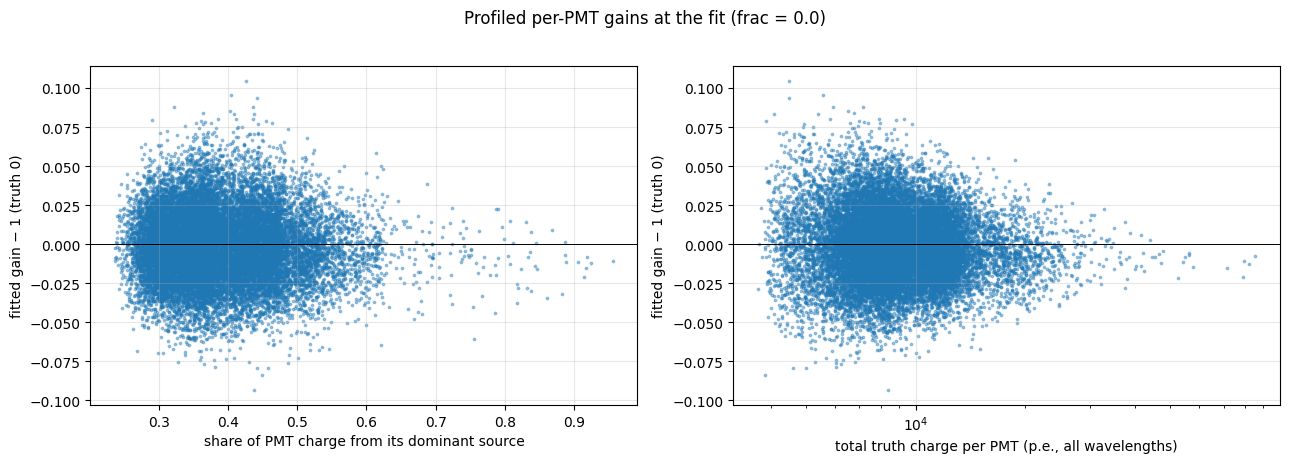

frac = 0.0: brightest 1% of PMTs carry 3% of the GN weight, brightest 10% carry 18%
frac = 0.02: brightest 1% of PMTs carry 2% of the GN weight, brightest 10% carry 16%


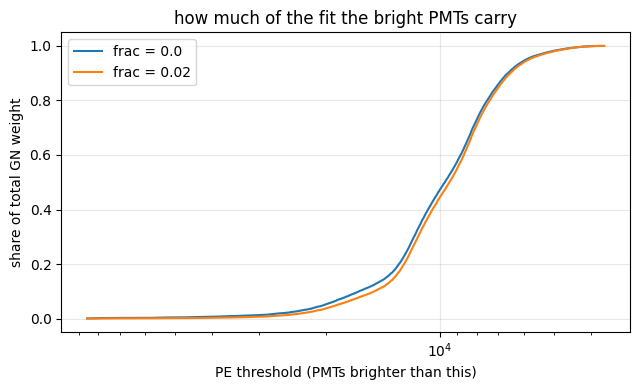

In [6]:
# Profiled per-PMT gains (as in calibration_gradients.ipynb), then the Gauss-Newton weight vs PE.
# Each (wavelength, source, PMT) bin enters the fit with Neyman weight Q^2 / var,
# var = clip(Q, floor) + (frac Q)^2: ~Q (Poisson) for dim PMTs, capped at 1/frac^2 for bright ones.
if 'truth_charge' not in r.files:
    print('no truth_charge in this results file (rerun the updated job)')
else:
    Qs = r['truth_charge'].sum(0)                                          # (source, NS), over wl
    Q = r['truth_charge'].reshape(-1, r['truth_charge'].shape[-1])         # (wl*source, NS)
    tot = Qs.sum(0)
    dom = Qs.max(0) / np.where(tot > 0, tot, 1)                            # dominant-source share
    k = r['gains'] / r['truth_k'] - 1
    frac_run = float(r['frac']) if 'frac' in r.files else 0.0
    lit = tot > 0

    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    ax[0].scatter(dom[lit], k[lit], s=3, alpha=.4)
    ax[1].scatter(tot[lit], k[lit], s=3, alpha=.4)
    for a in ax:
        a.axhline(0, color='k', lw=.7); a.set_ylabel('fitted gain − 1 (truth 0)'); a.grid(alpha=.3)
    ax[0].set_xlabel('share of PMT charge from its dominant source')
    ax[1].set_xscale('log'); ax[1].set_xlabel('total truth charge per PMT (p.e., all wavelengths)')
    fig.suptitle(f'Profiled per-PMT gains at the fit (frac = {frac_run})', y=1.02)
    fig.tight_layout(); plt.show()

    floor = 0.01 * Q.mean()
    def weight(f):
        return (Q ** 2 / (np.clip(Q, floor, None) + (f * Q) ** 2)).sum(0)  # per PMT

    order = np.argsort(tot)[::-1]
    plt.figure(figsize=(6.5, 4))
    for f in sorted({0.0, frac_run or 0.02}):
        w = weight(f)[order]; s = np.cumsum(w) / w.sum()
        plt.plot(tot[order], s, label=f'frac = {f}')
        print(f'frac = {f}: brightest 1% of PMTs carry {s[len(s) // 100]:.0%} of the GN weight, '
              f'brightest 10% carry {s[len(s) // 10]:.0%}')
    plt.xscale('log'); plt.gca().invert_xaxis(); plt.grid(alpha=.3); plt.legend()
    plt.xlabel('PE threshold (PMTs brighter than this)'); plt.ylabel('share of total GN weight')
    plt.title('how much of the fit the bright PMTs carry'); plt.tight_layout(); plt.show()